# Multi-label EEG classification

## Goal

We want to predict three diagnoses from each subject's resting-state EEG:
**Depression**, **SAD**, and **Phobia**. A subject can have more than one diagnosis,
so we fit one binary classifier per diagnosis.

This notebook compares two deliberately simple pipelines:

1. **State-aware MDM** compares covariance matrices using Riemannian distance.
2. **Tangent space + logistic regression** turns the covariance matrices into a
   small set of numerical features before classification.

Both pipelines use the same subjects, the same EEG preprocessing, and the same
cross-validation folds.

## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from pcp_project.classify import (
    StateAwareMDM,
    StateTangentFeatures,
    build_classification_pipeline,
    make_subject_folds,
)
from pcp_project.data import list_subject_ids, load_labels, load_subject

RANDOM_STATE = 7
N_SPLITS = 3
TARGET_COLUMNS = {
    "Depression": "SCID5_CV_Depression",
    "SAD": "SCID5_CV_SAD",
    "Phobia": "SCID5_CV_PHOB",
}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pcp_project").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(
    os.environ.get("PCP_DATA_DIR", PROJECT_ROOT / "data" / "data-20260528")
)

## Load the subjects and labels

We keep every subject who has both an EEG recording and a row in the label file.

In [2]:
labels = load_labels(DATA_DIR / "labels_reduced.csv")
subject_ids = [
    subject_id
    for subject_id in list_subject_ids(DATA_DIR)
    if subject_id in labels.index
]

target_frame = (
    labels.loc[subject_ids, list(TARGET_COLUMNS.values())]
    .rename(columns={column: name for name, column in TARGET_COLUMNS.items()})
    .astype(int)
)

y = target_frame.to_numpy()
groups = np.asarray(subject_ids)

assert y.shape == (len(subject_ids), len(TARGET_COLUMNS))
assert not target_frame.isna().any().any()

positive_counts = target_frame.sum()
print(f"Matched EEG subjects: {len(subject_ids)}")
positive_counts.to_frame("subjects with diagnosis")

Matched EEG subjects: 44


,subjects with diagnosis
Depression,21
SAD,21
Phobia,13


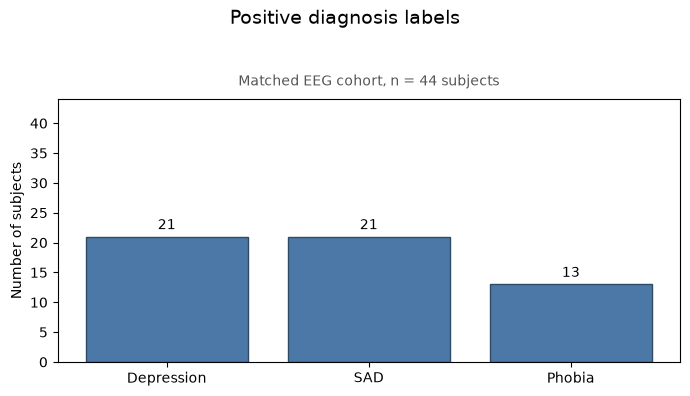

In [3]:
figure, axis = plt.subplots(figsize=(7, 4))
bars = axis.bar(
    positive_counts.index,
    positive_counts.values,
    color="#4C78A8",
    edgecolor="#2F4B63",
)
axis.bar_label(bars, padding=3)
axis.set_ylim(0, len(subject_ids))
axis.set_ylabel("Number of subjects")
figure.suptitle("Positive diagnosis labels", y=0.98, fontsize=14)
axis.set_title(
    f"Matched EEG cohort, n = {len(subject_ids)} subjects",
    fontsize=10,
    color="#555555",
    pad=10,
)
figure.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Create one covariance matrix per state and subject

The project library filters each recording, makes two-second windows, estimates an
OAS covariance matrix for each window, and averages the windows within each recording
state. We keep eyes-open and eyes-closed covariances separate because both classifiers
use the state information.

The recordings are processed one at a time to keep memory use small. This preprocessing
uses no diagnosis labels.

In [4]:
covariance_extractor = build_classification_pipeline(
    classifier="passthrough",
    window_seconds=2.0,
    covariance="oas",
    aggregation="stack",
    state_order=(0, 1),
    feature_transform="identity",
)

covariance_rows = []
for index, subject_id in enumerate(subject_ids):
    subject = load_subject(subject_id, DATA_DIR)
    if index == 0:
        covariance_extractor.fit([subject])
    covariance_rows.append(covariance_extractor.transform([subject])[0])

subject_state_covariances = np.stack(covariance_rows)

print("Covariance tensor:", subject_state_covariances.shape)
print("(subjects, states, channels, channels)")

Covariance tensor: (44, 2, 61, 61)
(subjects, states, channels, channels)


## Define the two pipelines

### Pipeline 1: state-aware MDM

MDM finds a covariance mean for the positive and negative class of each diagnosis.
A new subject is assigned to the closer mean. This keeps the covariance matrices in
their original Riemannian geometry.

### Pipeline 2: tangent space + logistic regression

Each recording state is mapped to tangent-space features. We standardize the features,
reduce them to five principal components, and fit one logistic regression per diagnosis.
PCA is useful here because 44 subjects is small compared with the number of tangent-space
features.

All learned transformations are fitted again inside each training fold.

In [5]:
mdm_pipeline = OneVsRestClassifier(StateAwareMDM())

tangent_logistic_pipeline = make_pipeline(
    StateTangentFeatures(),
    StandardScaler(),
    PCA(n_components=5, svd_solver="full"),
    OneVsRestClassifier(
        LogisticRegression(
            C=1.0,
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
    ),
)

pipelines = {
    "State-aware MDM": mdm_pipeline,
    "Tangent space + logistic regression": tangent_logistic_pipeline,
}

pd.DataFrame(
    {
        "Pipeline": list(pipelines),
        "Main idea": [
            "Closest covariance mean",
            "Five tangent-space components",
        ],
    }
).set_index("Pipeline")

,Main idea
Pipeline,
State-aware MDM,Closest covariance mean
Tangent space + logistic regression,Five tangent-space components


## Cross-validated predictions

We use three subject-disjoint folds. Every prediction below is made for a subject that
was not used to fit that fold's model.

We report one metric: **mean balanced accuracy**. For each diagnosis, balanced accuracy
averages the accuracy on positive and negative subjects. We then average the three
diagnosis scores. A value of 0.5 is the no-skill reference, and 1.0 is perfect.

In [6]:
folds = make_subject_folds(
    y,
    groups,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

assert all(
    set(groups[train_index]).isdisjoint(groups[test_index])
    for train_index, test_index in folds
)

predictions = {
    name: cross_val_predict(
        pipeline,
        subject_state_covariances,
        y,
        cv=folds,
        method="predict",
    )
    for name, pipeline in pipelines.items()
}

per_label_accuracy = pd.DataFrame(
    {
        name: [
            balanced_accuracy_score(y[:, label_index], predicted[:, label_index])
            for label_index in range(y.shape[1])
        ]
        for name, predicted in predictions.items()
    },
    index=TARGET_COLUMNS,
)

overall_accuracy = per_label_accuracy.mean().rename("Mean balanced accuracy")
print(overall_accuracy.round(3).to_string())

State-aware MDM                        0.476
Tangent space + logistic regression    0.571


## Results

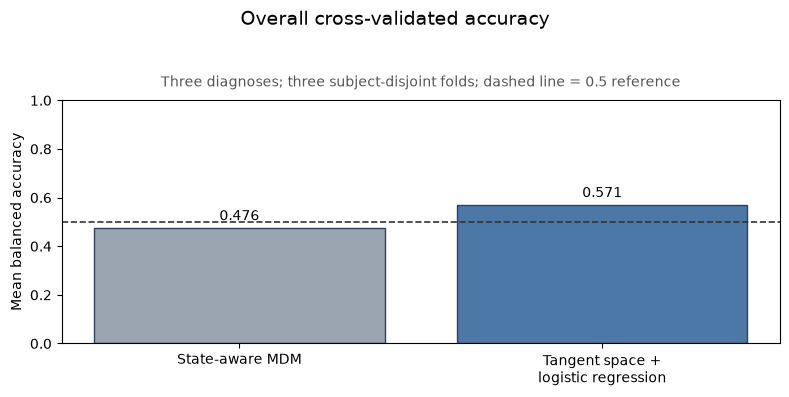

In [7]:
figure, axis = plt.subplots(figsize=(8, 4))
colors = ["#9AA5B1", "#4C78A8"]
display_names = ["State-aware MDM", "Tangent space +\nlogistic regression"]
bars = axis.bar(
    display_names,
    overall_accuracy.values,
    color=colors,
    edgecolor="#334155",
)
axis.axhline(0.5, color="#333333", linestyle="--", linewidth=1.2)
axis.bar_label(bars, labels=[f"{value:.3f}" for value in overall_accuracy], padding=3)
axis.set_ylim(0, 1)
axis.set_ylabel("Mean balanced accuracy")
figure.suptitle("Overall cross-validated accuracy", y=0.98, fontsize=14)
axis.set_title(
    "Three diagnoses; three subject-disjoint folds; dashed line = 0.5 reference",
    fontsize=10,
    color="#555555",
    pad=10,
)
figure.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

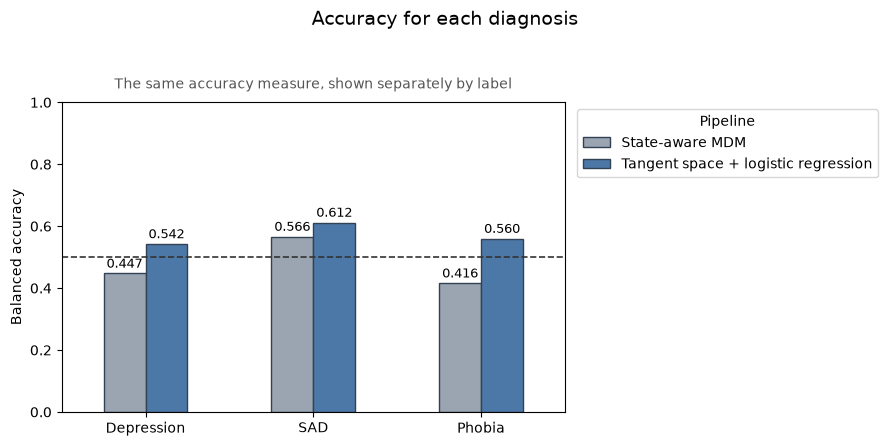

In [8]:
figure, axis = plt.subplots(figsize=(9, 4.5))
per_label_accuracy.plot.bar(
    ax=axis,
    color=["#9AA5B1", "#4C78A8"],
    edgecolor="#334155",
    rot=0,
)
axis.axhline(0.5, color="#333333", linestyle="--", linewidth=1.2)
axis.set_ylim(0, 1)
axis.set_xlabel("")
axis.set_ylabel("Balanced accuracy")
figure.suptitle("Accuracy for each diagnosis", y=0.98, fontsize=14)
axis.set_title(
    "The same accuracy measure, shown separately by label",
    fontsize=10,
    color="#555555",
    pad=10,
)
axis.legend(title="Pipeline", loc="upper left", bbox_to_anchor=(1.01, 1))
for container in axis.containers:
    axis.bar_label(container, fmt="%.3f", padding=2, fontsize=9)
figure.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Conclusion

The **tangent-space logistic regression** pipeline reached a mean balanced accuracy of
**0.571**, compared with **0.476** for state-aware MDM. Its accuracy was above the 0.5
reference for all three diagnoses, while MDM was above 0.5 only for SAD.

This comparison does not tell us which individual step caused the difference, but it
shows that the small tangent-space representation worked better for these folds.